# 머신러닝 심화 II — 분류 모델 비교 · 튜닝 · Stacking · SHAP
## Titanic 데이터 기반 Pipeline Ensemble 실습

이 노트북은 `분류_튜토리얼_Part1~3.ipynb`의 Titanic 분류 흐름을 확장합니다.

**핵심 목표**
- **train/test 분리 후** `X_train` 기준으로 파생변수를 생성하고, 동일 함수를 `X_test`에 적용합니다.
- **sklearn 1.6.1** API 기준 `Pipeline` + `ColumnTransformer` + `OneHotEncoder(sparse_output=False)` 를 사용합니다.
- 10개 분류 모델을 **과적합을 억제하는 탐색 공간**으로 `RandomizedSearchCV` 튜닝합니다.
- `StratifiedKFold`로 클래스 비율을 유지한 교차검증을 수행합니다.
- 상위 모델을 `StackingClassifier`로 앙상블합니다.
- **SHAP**으로 최종 모델의 변수 기여도를 해석합니다.
- 테스트 데이터는 **마지막 최종 평가**에만 사용합니다.

**사용 모델 10개**
LogisticRegression · GaussianNB · DecisionTree · RandomForest · GradientBoosting · KNN · SVC · XGBoost · LightGBM · CatBoost


## 1. 환경 설정

In [1]:
!pip install scikit-learn==1.6.1 xgboost lightgbm catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [2]:
import sys
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

In [3]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import shap  # 설명 가능한 AI(XAI) 라이브러리: 모델의 예측 결과에 각 특성(Feature)이 기여한 정도를 시각화

# 전처리 및 가공을 위한 scikit-learn 컴포넌트
from sklearn.compose import ColumnTransformer  # 컬럼별로 서로 다른 전처리(예: 수치형은 스케일링, 범주형은 원핫)를 다르게 적용할 때 사용
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier # 앙상블 및 모델 스태킹(여러 모델 결합)
from sklearn.impute import SimpleImputer       # 결측치를 평균, 중앙값, 최빈값 등으로 손쉽게 채워주는 도구
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (                  # 다양한 모델 평가 지표 및 오차행렬 시각화 도구
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split # 하이퍼파라미터 튜닝 및 데이터 분할
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline          # 데이터 전처리부터 모델 학습까지의 과정을 하나의 파이프라인으로 연결
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 현업 및 데이터 경진대회(캐글 등) 필수 정형데이터 부스팅 3대장 알고리즘
from xgboost import XGBClassifier              # eXtreme Gradient Boosting: 병렬 학습과 규제를 결합한 강력한 부스팅
from lightgbm import LGBMClassifier            # LightGBM: 대용량 데이터 처리가 빠르고 메모리 사용량이 적은 부스팅
from catboost import CatBoostClassifier        # CatBoost: 범주형 변수(Categorical) 처리에 특화되어 기본 성능이 뛰어난 부스팅

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# 경고 메시지 무시 설정
warnings.filterwarnings('ignore')

# 코드 실행 결과의 재현성을 위한 난수 생성(Random Seed) 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 환경 구축 결과 출력 확인
print('sklearn version:', sklearn.__version__)
print('환경 설정 완료')

sklearn version: 1.6.1
환경 설정 완료


## 2. 데이터 로드 및 변수 선택

In [4]:
import seaborn as sns

# 1. 시본(Seaborn)의 내장 타이타닉 데이터셋 로드
titanic = sns.load_dataset('titanic')

# 2. 분석 및 예측 모델 학습에 사용할 기본 피처(독립변수) 정의
base_features = [
    'pclass', 'age', 'sibsp', 'parch', 'fare',
    'sex', 'embarked', 'who', 'adult_male', 'alone',
]
# 예측할 목표 변수(종속변수) 정의
target = 'survived' # 0: 사망, 1: 생존

# 3. 원본 데이터 훼손을 방지하기 위해 .copy()를 사용하여 독립변수와 타깃을 완전히 분리
X = titanic.loc[:, base_features].copy()
y = titanic.loc[:, target].copy()

# 4. 분리된 독립변수(X)의 행과 열 구조(Shape) 출력
# 출력 예시: X shape: (891, 10) -> 891개의 행(탑승객)과 10개의 열(특성)
print('X shape:', X.shape)

# 5. 종속변수(y)인 생존율 데이터 분포 확인
print('y distribution:')
# value_counts(normalize=True): 사망(0)과 생존(1)의 비율을 백분율(0~1 사이)로 계산
# sort_index(): 0(사망)부터 순서대로 정렬
# round(3): 소수점 셋째 자리까지 반올림하여 출력
print(y.value_counts(normalize=True).sort_index().round(3))

# 6. 독립변수 데이터프레임(X)의 상위 5개 행을 출력하여 데이터 확인
X.head()

X shape: (891, 10)
y distribution:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


,pclass,age,sibsp,parch,fare,sex,embarked,who,adult_male,alone
0,3,22.0,1,0,7.2500,male,S,man,True,False
1,1,38.0,1,0,71.2833,female,C,woman,False,False
2,3,26.0,0,0,7.9250,female,S,woman,False,True
3,1,35.0,1,0,53.1000,female,S,woman,False,False
4,3,35.0,0,0,8.0500,male,S,man,True,True


## 3. 층화추출 Train/Test Split 후 파생변수 생성

- **분리 먼저 → `X_train`에서 파생변수 생성 → 같은 함수를 `X_test`에 적용**합니다.
- 타깃(`survived`)을 사용하지 않는 결정론적 파생변수만 추가합니다.


In [5]:
# =================================================================
# 1) 층화추출(Stratified Sampling)로 Train / Test 세트 분리
# =================================================================
# stratify=y 옵션을 주어 원본 데이터의 생존율(y) 비율을 Train과 Test에 그대로 유지합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 분리 직후 데이터의 크기(Shape)와 클래스 비율(생존율)이 잘 맞는지 검증 출력
print('분리 직후 train:', X_train.shape, 'survived rate=', y_train.mean().round(3))
print('분리 직후 test :', X_test.shape, 'survived rate=', y_test.mean().round(3))


# =================================================================
# 2) 파생 변수(Feature Engineering) 생성 함수 정의
# =================================================================
def add_titanic_features(df):
    """타깃 정보(y)를 참조하지 않는 순수 독립변수 기반 Titanic 파생변수 생성 함수.

    FamilySize     : 형제/배우자수(sibsp) + 부모/자녀수(parch) + 본인(1)
    IsAlone        : 혼자 탑승한 1인 승객 여부 (1: 혼자, 0: 가족 동반)
    FarePerPerson  : 전체 티켓 요금을 가족 수로 나눈 인당 요금
    """
    out = df.copy() # SettingWithCopyWarning 방지 및 원본 데이터 보존을 위한 카피
    out.loc[:, 'FamilySize'] = out.loc[:, 'sibsp'] + out.loc[:, 'parch'] + 1
    out.loc[:, 'IsAlone'] = (out.loc[:, 'FamilySize'] == 1).astype(int)
    out.loc[:, 'FarePerPerson'] = out.loc[:, 'fare'] / out.loc[:, 'FamilySize']
    return out


# =================================================================
# 3) 정의한 파생 변수 함수를 Train과 Test에 각각 수동 적용
# =================================================================
# 데이터 분할(split)을 먼저 진행한 뒤 함수를 따로 적용함으로써 데이터 누수(Leakage)를 엄격히 차단합니다.
X_train = add_titanic_features(X_train) # 학습 데이터에 먼저 적용
X_test = add_titanic_features(X_test)   # 동일한 규칙과 함수를 테스트 데이터에도 적용


# =================================================================
# 4) 향후 전처리 파이프라인 매핑을 위한 피처 세트 분류 및 타입 통일
# =================================================================
# 수치형 변수 리스트 (새로 만든 파생 변수 3종 포함)
numeric_features = [
    'pclass', 'age', 'sibsp', 'parch', 'fare',
    'FamilySize', 'IsAlone', 'FarePerPerson',
    'adult_male', 'alone',
]
# 범주형 변수 리스트
categorical_features = ['sex', 'embarked', 'who']

# 범주형 컬럼 내 데이터 타입을 문자열(str)로 통일
# 향후 사이킷런의 SimpleImputer(최빈값) 및 OneHotEncoder가 결측치나 불일치 없이 정상 작동하도록 돕는 안전장치입니다.
for col in categorical_features:
    X_train.loc[:, col] = X_train.loc[:, col].astype(str)
    X_test.loc[:, col] = X_test.loc[:, col].astype(str)

# 파생 변수가 추가되어 열(Columns)의 개수가 늘어났는지 최종 구조 확인
print('파생변수 적용 후 train:', X_train.shape)
print('파생변수 적용 후 test :', X_test.shape)

# 최종 정제된 훈련 데이터프레임의 상위 5개 데이터 확인
X_train.head()

분리 직후 train: (712, 10) survived rate= 0.383
분리 직후 test : (179, 10) survived rate= 0.385
파생변수 적용 후 train: (712, 13)
파생변수 적용 후 test : (179, 13)


,pclass,age,sibsp,parch,fare,sex,embarked,who,adult_male,alone,FamilySize,IsAlone,FarePerPerson
692,3,NaN,0,0,56.4958,male,S,man,True,True,1,1,56.4958
481,2,NaN,0,0,0.0000,male,S,man,True,True,1,1,0.0000
527,1,NaN,0,0,221.7792,male,S,man,True,True,1,1,221.7792
855,3,18.0,0,1,9.3500,female,S,woman,False,False,2,0,4.6750
801,2,31.0,1,1,26.2500,female,S,woman,False,False,3,0,8.7500


## 4. 공통 Pipeline 전처리 (sklearn 1.6.1)

- 수치형: `SimpleImputer(strategy='median')` + `StandardScaler`
- 범주형: `SimpleImputer(strategy='most_frequent')` + `OneHotEncoder(sparse_output=False)`

> sklearn 1.6.1 기준 `sparse_output=False` 를 사용합니다. (`make_onehot` 헬퍼 불필요)


In [6]:
# 1. 수치형 변수(Numeric Features) 전처리 파이프라인 정의
# 수치 데이터의 결측치를 채우고 스케일을 균일하게 맞추는 작업을 한 묶음으로 정의합니다.
numeric_transformer = Pipeline([
    # Step 1: 결측치(NaN)를 해당 컬럼의 '중앙값(median)'으로 대체
    ('imputer', SimpleImputer(strategy='median')),

    # Step 2: 데이터의 평균을 0, 표준편차를 1로 만드는 표준화(Standardization) 수행
    ('scaler', StandardScaler()),
])

# 2. 범주형 변수(Categorical Features) 전처리 파이프라인 정의
# 문자열 데이터의 결측치를 채우고 모델이 연산할 수 있는 숫자로 펼쳐주는 인코딩 작업을 정의합니다.
categorical_transformer = Pipeline([
    # Step 1: 결측치(NaN)를 해당 컬럼에서 가장 자주 등장한 '최빈값(most_frequent)'으로 대체
    ('imputer', SimpleImputer(strategy='most_frequent')),

    # Step 2: 원-핫 인코딩(One-Hot Encoding)을 적용해 카테고리를 0과 1의 독립된 열들로 확장
    # handle_unknown='ignore': 나중에 테스트 세트에서 처음 보는 카테고리가 나와도 에러 없이 0 처리하도록 설정
    # sparse_output=False: 결과를 압축 배열이 아닌 표준 넘파이 배열(Dense Array)로 반환
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# 3. 데이터 타입별 전처리기들을 하나의 컬럼 변환기(ColumnTransformer)로 병합
# 전체 데이터프레임이 들어오면 정의된 피처 리스트에 맞게 각 파이프라인으로 알아서 찢어서 넣어줍니다.
preprocessor = ColumnTransformer([
    # ('이름', 적용할 파이프라인, 적용할 피처 목록)
    ('num', numeric_transformer, numeric_features),       # 수치형 변수 영역 처리 매핑
    ('cat', categorical_transformer, categorical_features), # 범주형 변수 영역 처리 매핑
])

# 4. 모델 검증 및 신뢰성 평가를 위한 교차 검증(Cross Validation) 전략 정의
# StratifiedKFold: 타깃 클래스(생존 여부) 비율을 모든 폴드에 균일하게 복사하여 5개(n_splits)의 조각으로 나눕니다.
# shuffle=True: 데이터를 무작위로 한 번 섞어서 특정 순서 편향을 방지합니다.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 설정 준비 완료 메시지 출력
print('공통 전처리와 StratifiedKFold 준비 완료')

공통 전처리와 StratifiedKFold 준비 완료


## 5. 10개 모델과 튜닝 공간 정의

각 모델의 탐색 범위는 **공식 문서의 regularization / tree complexity 파라미터**를 참고해 과적합을 줄이는 방향으로 설정했습니다.

| 모델 | 과적합 억제 포인트 (문서 기준) |
|------|-------------------------------|
| LogisticRegression | 작은 `C` → 규제 강화 |
| GaussianNB | 큰 `var_smoothing` → 분산 평활화 |
| DecisionTree | `max_depth`, `min_samples_leaf`, `min_samples_split` 제한 |
| RandomForest | `max_depth` 상한, `min_samples_leaf`, `max_features` 축소 |
| GradientBoosting | 얕은 트리, `subsample` < 1 |
| KNN | `n_neighbors` 증가 |
| SVC | 작은 `C`, 보수적 `gamma` |
| XGB / LGBM / CatBoost | `max_depth/depth` 제한, `reg_*`, `min_child_*`, `subsample` |


In [7]:
from scipy.stats import randint, uniform, loguniform

# =================================================================
# 트리 계열 모델 공통 하이퍼파라미터 분포 (RandomizedSearchCV용)
# =================================================================
COMMON_N_ESTIMATORS   = randint(100, 300)      # 트리 개수: 100~299
COMMON_MAX_DEPTH       = randint(3, 11)         # 트리 최대 깊이: 3~10
COMMON_LEARNING_RATE   = uniform(0.01, 0.19)    # 학습률: 0.01~0.20
COMMON_SUBSAMPLE       = uniform(0.6, 0.35)     # 행 샘플링 비율: 0.6~0.95
COMMON_MIN_SAMPLES_LEAF  = randint(2, 21)       # 리프 최소 샘플 수: 2~20
COMMON_MIN_SAMPLES_SPLIT = randint(5, 41)       # 분할 최소 샘플 수: 5~40
COMMON_REG_LAMBDA      = loguniform(1e-1, 1e1)  # L2 규제 계수: 0.1~10 (로그 스케일)

model_grids = {
    'LogisticRegression': (
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        {
            'model__C': loguniform(1e-2, 1e1),
            'model__penalty': ['l2'],
        },
    ),
    'GaussianNB': (
        GaussianNB(),
        {'model__var_smoothing': loguniform(1e-9, 1e-5)},
    ),

    # =================================================================
    # 트리 계열 모델 (공통 파라미터 통일)
    # =================================================================
    'DecisionTree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            'model__max_depth': COMMON_MAX_DEPTH,
            'model__min_samples_leaf': COMMON_MIN_SAMPLES_LEAF,
            'model__min_samples_split': COMMON_MIN_SAMPLES_SPLIT,
        },
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'model__n_estimators': COMMON_N_ESTIMATORS,
            'model__max_depth': COMMON_MAX_DEPTH,
            'model__min_samples_leaf': COMMON_MIN_SAMPLES_LEAF,
            'model__min_samples_split': COMMON_MIN_SAMPLES_SPLIT,
            'model__max_features': ['sqrt', 0.5],
        },
    ),
    'GradientBoosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            'model__n_estimators': COMMON_N_ESTIMATORS,
            'model__learning_rate': COMMON_LEARNING_RATE,
            'model__max_depth': COMMON_MAX_DEPTH,
            'model__subsample': COMMON_SUBSAMPLE,
            'model__min_samples_leaf': COMMON_MIN_SAMPLES_LEAF,
        },
    ),
    'XGBoost': (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1),
        {
            'model__n_estimators': COMMON_N_ESTIMATORS,
            'model__max_depth': COMMON_MAX_DEPTH,
            'model__learning_rate': COMMON_LEARNING_RATE,
            'model__subsample': COMMON_SUBSAMPLE,
            'model__reg_lambda': COMMON_REG_LAMBDA,
        },
    ),
    'LightGBM': (
        LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        {
            'model__n_estimators': COMMON_N_ESTIMATORS,
            'model__max_depth': COMMON_MAX_DEPTH,
            'model__learning_rate': COMMON_LEARNING_RATE,
            'model__subsample': COMMON_SUBSAMPLE,
            'model__reg_lambda': COMMON_REG_LAMBDA,
        },
    ),
    'CatBoost': (
        CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, loss_function='Logloss'),
        {
            'model__iterations': COMMON_N_ESTIMATORS,      # n_estimators와 대칭
            'model__depth': COMMON_MAX_DEPTH,               # max_depth와 대칭
            'model__learning_rate': COMMON_LEARNING_RATE,
            'model__subsample': COMMON_SUBSAMPLE,
            'model__l2_leaf_reg': COMMON_REG_LAMBDA,        # reg_lambda와 대칭
        },
    ),

    # =================================================================
    # 그 외 모델
    # =================================================================
    'KNN': (
        KNeighborsClassifier(),
        {
            'model__n_neighbors': randint(5, 22),
            'model__weights': ['uniform'],
        },
    ),
    'SVC': (
        SVC(probability=True, random_state=RANDOM_STATE),
        {
            'model__C': loguniform(1e-1, 1e1),
            'model__gamma': ['scale', 0.1],
            'model__kernel': ['rbf'],
        },
    ),
}

print('모델 개수:', len(model_grids))

모델 개수: 10


## 6. 모델별 튜닝 및 교차검증 비교

각 모델은 `Pipeline(preprocessor + model)` 로 감싼 뒤 `RandomizedSearchCV`를 수행합니다.
평가 지표는 **ROC-AUC**이며, train/validation gap으로 과적합을 함께 확인합니다.


In [8]:
from sklearn.model_selection import RandomizedSearchCV
from tqdm.auto import tqdm
import time
import pandas as pd

# 1. 하이퍼파라미터 랜덤 탐색을 위한 RandomizedSearchCV 기반 튜닝 함수 정의
def tune_classification_model(name, estimator, param_distributions, n_iter=50):
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        return_train_score=True,
    )

    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    fit_time_sec = time.perf_counter() - t0

    best_idx = search.best_index_

    return search, {
        'model': name,
        'fit_time_sec': fit_time_sec,
        'train_roc_auc': search.cv_results_['mean_train_score'][best_idx],
        'valid_roc_auc': search.cv_results_['mean_test_score'][best_idx],
        'valid_std': search.cv_results_['std_test_score'][best_idx],
        'overfit_gap': search.cv_results_['mean_train_score'][best_idx] - search.cv_results_['mean_test_score'][best_idx],
        'best_params': search.best_params_,
    }

# 2. 모델 객체 및 평가지표 결과 행을 담을 저장소 초기화
search_objects = {}
rows = []

# 3. tqdm으로 감싼 반복문을 돌며 model_grids 내부의 10개 모델 순차 튜닝 진행
progress_bar = tqdm(model_grids.items(), total=len(model_grids), desc='모델 튜닝 진행률')

for name, (estimator, param_distributions) in progress_bar:
    # 진행바 우측에 현재 처리 중인 모델명 표시
    progress_bar.set_postfix_str(name)

    search, row = tune_classification_model(name, estimator, param_distributions)

    search_objects[name] = search
    rows.append(row)

# 4. 전체 모델의 성능을 비교하기 위한 튜닝 리더보드 데이터프레임 빌드
leaderboard = (
    pd.DataFrame(rows)
    .sort_values('valid_roc_auc', ascending=False)
    .reset_index(drop=True)
)

# 5. 리더보드 가독성을 위해 핵심 평가 컬럼만 선택 후 소수점 4자리까지 반올림하여 최종 출력
leaderboard.loc[:, [
    'model', 'fit_time_sec', 'train_roc_auc',
    'valid_roc_auc', 'valid_std', 'overfit_gap'
]].round(4)

모델 튜닝 진행률:   0%|          | 0/10 [00:00<?, ?it/s]

,model,fit_time_sec,train_roc_auc,valid_roc_auc,valid_std,overfit_gap
0,CatBoost,146.8187,0.9768,0.8927,0.0189,0.0841
1,GradientBoosting,156.3481,0.9618,0.8907,0.0232,0.0712
2,XGBoost,31.2540,0.9507,0.8892,0.0226,0.0615
3,LightGBM,93.7996,0.9423,0.8872,0.0223,0.0551
4,RandomForest,123.6447,0.9546,0.8860,0.0272,0.0686
5,DecisionTree,9.5373,0.9119,0.8820,0.0222,0.0299
6,LogisticRegression,20.8464,0.8720,0.8647,0.0213,0.0073
7,KNN,8.9577,0.8986,0.8628,0.0315,0.0358
8,SVC,27.1363,0.8989,0.8491,0.0329,0.0498
9,GaussianNB,9.5433,0.8500,0.8436,0.0249,0.0064


## 7. 모델 비교 시각화

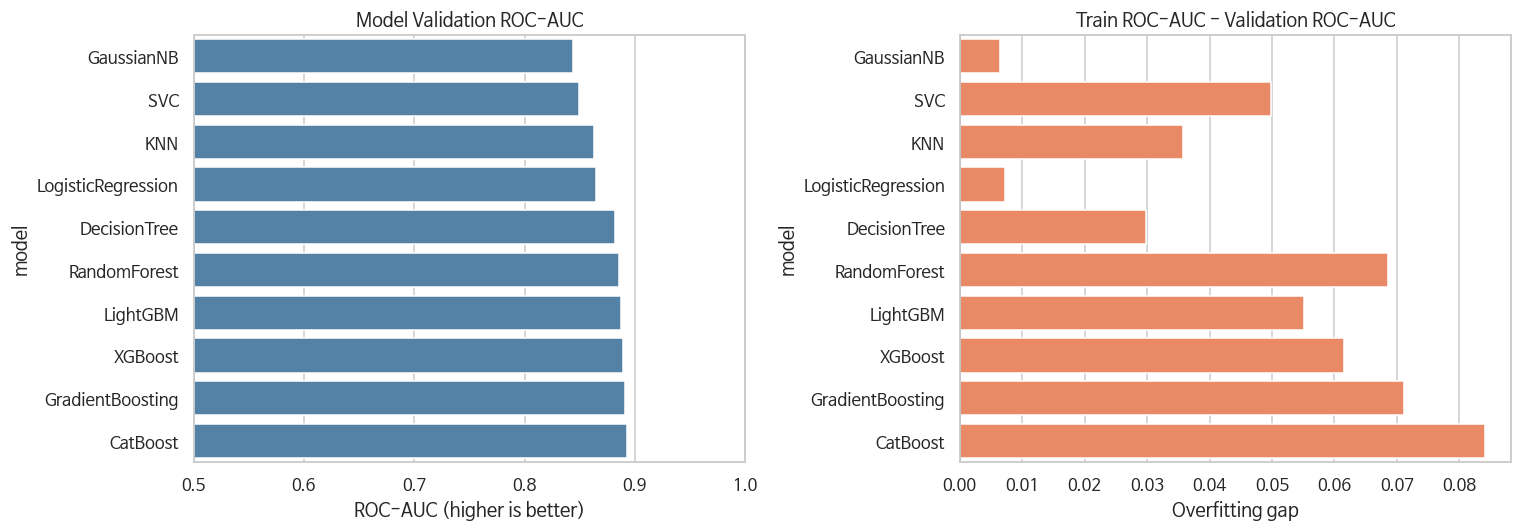

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = leaderboard.sort_values('valid_roc_auc', ascending=True)
sns.barplot(data=plot_df, x='valid_roc_auc', y='model', ax=axes[0], color='steelblue')
axes[0].set_title('Model Validation ROC-AUC')
axes[0].set_xlabel('ROC-AUC (higher is better)')
axes[0].set_xlim(0.5, 1.0)

sns.barplot(data=plot_df, x='overfit_gap', y='model', ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Train ROC-AUC - Validation ROC-AUC')
axes[1].set_xlabel('Overfitting gap')

plt.tight_layout()
plt.show()

### 7-1. 성능 vs 학습시간 사분면

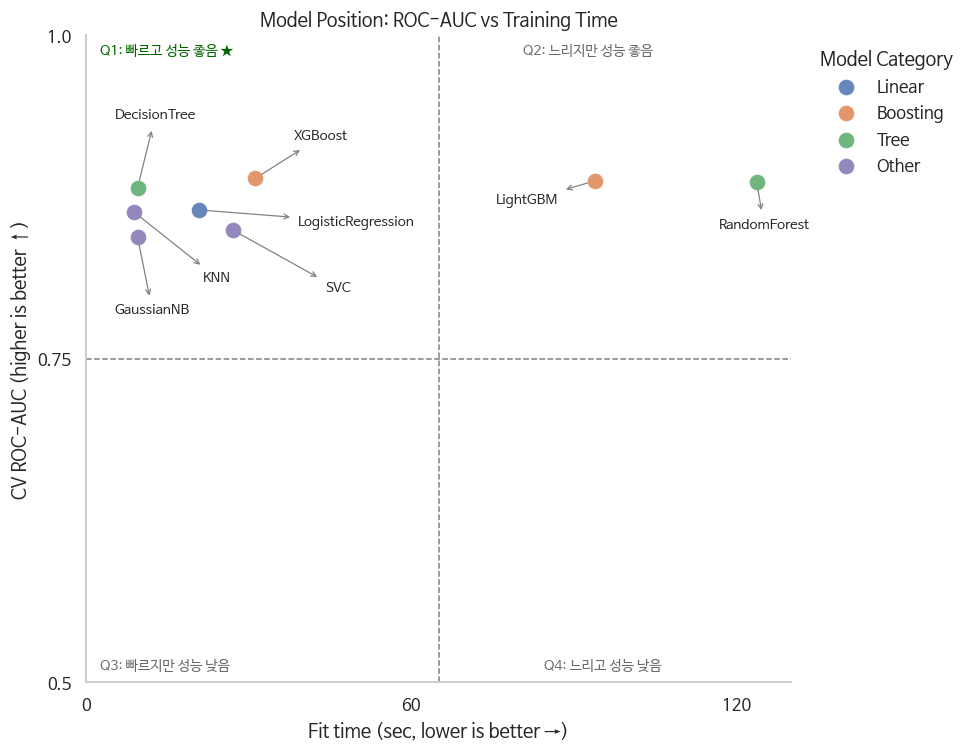

,model,category,fit_time_sec,valid_roc_auc,overfit_gap
7,KNN,Other,8.9577,0.8628,0.0358
5,DecisionTree,Tree,9.5373,0.8820,0.0299
9,GaussianNB,Other,9.5433,0.8436,0.0064
6,LogisticRegression,Linear,20.8464,0.8647,0.0073
8,SVC,Other,27.1363,0.8491,0.0498
2,XGBoost,Boosting,31.2540,0.8892,0.0615
3,LightGBM,Boosting,93.7996,0.8872,0.0551
4,RandomForest,Tree,123.6447,0.8860,0.0686
0,CatBoost,Boosting,146.8187,0.8927,0.0841
1,GradientBoosting,Boosting,156.3481,0.8907,0.0712


In [10]:
# 성능(↑) vs 학습시간(→) 사분면: 좌상단 = 빠르고 정확 (이상적) + 모델 계열별 색상 구분 + 겹치는 라벨 화살표 처리
quad_df = leaderboard.copy()
quad_df.loc[:, 'score'] = quad_df.loc[:, 'valid_roc_auc']

model_category = {
    'Ridge': 'Linear',
    'Lasso': 'Linear',
    'LogisticRegression': 'Linear',
    'CatBoost': 'Boosting',
    'XGBoost': 'Boosting',
    'GradientBoosting': 'Boosting',
    'LightGBM': 'Boosting',
    'DecisionTree': 'Tree',
    'RandomForest': 'Tree',
    'KNN': 'Other',
    'SVC': 'Other',
    'SVR': 'Other',
    'GaussianNB': 'Other',
}
quad_df['category'] = quad_df['model'].map(model_category).fillna('Other')

category_colors = {
    'Linear': '#4C72B0',
    'Boosting': '#DD8452',
    'Tree': '#55A868',
    'Other': '#8172B2',
}

label_offsets = {
    'DecisionTree': (-15, 45),
    'KNN': (45, -45),
    'GaussianNB': (-15, -50),
    'SVC': (60, -40),
    'XGBoost': (25, 25),
    'LogisticRegression': (65, -10),
    'RandomForest': (-25, -30),
    'GradientBoosting': (20, -15),
    'LightGBM': (-65, -15),
}
default_offset = (6, 4)

x_threshold = 65
y_med = 0.75

fig, ax = plt.subplots(figsize=(9, 7))

for cat, color in category_colors.items():
    sub = quad_df[quad_df['category'] == cat]
    if sub.empty:
        continue
    ax.scatter(
        sub['fit_time_sec'],
        sub['score'],
        s=120,
        alpha=0.85,
        c=color,
        edgecolors='white',
        linewidths=0.8,
        label=cat,
    )

for _, row in quad_df.iterrows():
    offset = label_offsets.get(row['model'], default_offset)
    if row['model'] in label_offsets:
        ax.annotate(
            row['model'],
            xy=(row['fit_time_sec'], row['score']),
            xytext=offset,
            textcoords='offset points',
            fontsize=9,
            arrowprops=dict(
                arrowstyle='<-',
                color='gray',
                lw=0.8,
                shrinkA=3,
                shrinkB=5,
                mutation_scale=8,   # XGBoost 등 화살표 머리 크기를 전체적으로 살짝 작게
            ),
        )
    else:
        ax.annotate(
            row['model'],
            xy=(row['fit_time_sec'], row['score']),
            xytext=offset,
            textcoords='offset points',
            fontsize=9,
        )

ax.set_xlim(0, 130)
ax.set_ylim(0.5, 1.0)

ax.axvline(x_threshold, color='gray', linestyle='--', linewidth=1)
ax.axhline(y_med, color='gray', linestyle='--', linewidth=1)

ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xticks([0, 60, 120])
ax.set_xticklabels(['0', '60', '120'])
ax.set_yticks([0.5, 0.75, 1.0])
ax.set_yticklabels(['0.5', '0.75', '1.0'])

ax.set_xlabel('Fit time (sec, lower is better →)')
ax.set_ylabel('CV ROC-AUC (higher is better ↑)')
ax.set_title('Model Position: ROC-AUC vs Training Time')

x_min, x_max_lim = ax.get_xlim()
y_min, y_max_lim = ax.get_ylim()
ax.text(x_min + 0.02 * (x_max_lim - x_min), y_max_lim - 0.03 * (y_max_lim - y_min), 'Q1: 빠르고 성능 좋음 ★', fontsize=9, color='darkgreen')
ax.text(x_max_lim - 0.38 * (x_max_lim - x_min), y_max_lim - 0.03 * (y_max_lim - y_min), 'Q2: 느리지만 성능 좋음', fontsize=9, color='dimgray')
ax.text(x_min + 0.02 * (x_max_lim - x_min), y_min + 0.02 * (y_max_lim - y_min), 'Q3: 빠르지만 성능 낮음', fontsize=9, color='dimgray')
ax.text(x_max_lim - 0.35 * (x_max_lim - x_min), y_min + 0.02 * (y_max_lim - y_min), 'Q4: 느리고 성능 낮음', fontsize=9, color='dimgray')

ax.legend(title='Model Category', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)

plt.tight_layout()
plt.show()

quad_df.loc[:, ['model', 'category', 'fit_time_sec', 'valid_roc_auc', 'overfit_gap']].sort_values('fit_time_sec').round(4)

## 8. 단일 Best 모델 테스트 평가

In [11]:
# 1. 랜덤 서치 리더보드 결과에서 가장 성적이 우수한(0번 인덱스) 모델명 추출
best_single_name = leaderboard.loc[0, 'model']

# 2. 최적 모델명에 해당하는 랜덤 서치 객체에서 최적의 파라미터로 최종 학습된 모델(Pipeline) 추출
best_single_model = search_objects[best_single_name].best_estimator_

# 3. 추출한 최적 모델을 사용하여 최종 테스트 데이터셋(X_test)에 대한 예측 수행
# best_single_model 내부에 전처리 파이프라인이 포함되어 있으므로 원본 데이터프레임을 그대로 입력합니다.
y_pred_single = best_single_model.predict(X_test)              # 최종 평가용 정답 클래스 예측값 (0: 사망, 1: 생존)
y_proba_single = best_single_model.predict_proba(X_test)[:, 1] # ROC-AUC 연산을 위한 1(생존)일 확률 스코어 추출

# 4. 사이킷런 평가 모듈을 활용하여 최종 테스트 세트 기준의 3대 대표 평가지표 연산
acc_single = accuracy_score(y_test, y_pred_single)  # 전체 예측 중 정답을 맞춘 비율 (정확도)
f1_single = f1_score(y_test, y_pred_single)         # 정밀도와 재현율의 조화평균 (불균형 데이터 필수 지표)
auc_single = roc_auc_score(y_test, y_proba_single)  # 모델의 클래스 분류 판별력 성능 (ROC-AUC)

# 5. 최적 모델 정보 및 3대 평가지표 결과 출력
print('Best single model:', best_single_name)
print('Best params:', search_objects[best_single_name].best_params_) # 랜덤 서치를 통해 낙점된 최적의 하이퍼파라미터 조합
print(f'Test Accuracy: {acc_single:.4f}')
print(f'Test F1      : {f1_single:.4f}')
print(f'Test ROC-AUC : {auc_single:.4f}')
print()

# 6. 세부 지표 분석을 위한 종합 분류 리포트(Classification Report) 출력
# target_names 지정을 통해 0과 1 결과를 '사망'과 '생존'이라는 단어로 매핑하여 가독성을 높입니다.
print(classification_report(y_test, y_pred_single, target_names=['사망', '생존']))

Best single model: CatBoost
Best params: {'model__depth': 3, 'model__iterations': 230, 'model__l2_leaf_reg': np.float64(5.2466345336252855), 'model__learning_rate': np.float64(0.13925843233167814), 'model__subsample': np.float64(0.7576747381893401)}
Test Accuracy: 0.8156
Test F1      : 0.7442
Test ROC-AUC : 0.8489

              precision    recall  f1-score   support

          사망       0.82      0.89      0.86       110
          생존       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



## 9. Stacking Classifier

상위 5개 튜닝 모델을 base learner로 사용하고, 규제가 적용된 `LogisticRegression`을 final estimator로 사용합니다.
`StackingClassifier` 내부 CV도 `StratifiedKFold`를 사용합니다.


In [12]:
from sklearn.base import BaseEstimator, ClassifierMixin

# =================================================================
# 1. CatBoost용 사이킷런 clone() 에러 방어용 커스텀 래퍼 클래스 정의
# =================================================================
class CloneSafeCatBoost(BaseEstimator, ClassifierMixin):
    """
    CatBoostClassifier는 일부 파라미터(l2_leaf_reg 등)를 내부적으로 재처리하면서
    sklearn의 clone()이 사용하는 '동일 객체(identity)' 체크를 통과하지 못해
    StackingClassifier 내부 교차검증 단계에서 RuntimeError를 일으킵니다.
    이 래퍼는 전달받은 하이퍼파라미터를 그대로 보관했다가 fit 시점에만
    실제 CatBoostClassifier를 새로 생성해, clone() 시 파라미터가 항상
    원본 그대로(동일 객체로) 보존되도록 만듭니다.
    """
    def __init__(self, **params):
        # 입력받은 모든 하이퍼파라미터를 인스턴스 내부 딕셔너리에 안전하게 보관
        self.params = params

    def fit(self, X, y, **fit_params):
        # 핏(fit)이 호출되는 시점에만 보관해 둔 하이퍼파라미터로 진짜 CatBoost 객체를 생성하여 데이터 누수를 방지
        self.model_ = CatBoostClassifier(**self.params)
        self.model_.fit(X, y, **fit_params)
        self.classes_ = self.model_.classes_ # 분류 클래스 속성(0, 1) 동기화
        return self

    def predict(self, X):
        # 실제 생성된 CatBoost 모델의 클래스 예측 기능 호출
        return self.model_.predict(X)

    def predict_proba(self, X):
        # 실제 생성된 CatBoost 모델의 확률 예측 기능 호출
        return self.model_.predict_proba(X)

    def get_params(self, deep=True):
        # 사이킷런 인터페이스와 호환되도록 파라미터 딕셔너리를 복사하여 반환
        return dict(self.params)

    def set_params(self, **params):
        # 외부에서 하이퍼파라미터 변경 요청 시 내부 딕셔너리를 업데이트
        self.params.update(params)
        return self


# =================================================================
# 2. 파이프라인 내부의 CatBoost 모델 안전 변환 헬퍼 함수 정의
# =================================================================
def make_stack_safe(fitted_pipeline):
    """StackingClassifier에 넣을 파이프라인 중 CatBoost 단계만
    clone-safe 래퍼로 교체합니다. 다른 모델은 그대로 반환합니다."""
    # 파이프라인의 최종 예측 모델 단계('model') 추출
    model_step = fitted_pipeline.named_steps['model']

    # 해당 모델이 CatBoostClassifier 인스턴스인 경우, 커스텀 방어 래퍼 클래스로 감싸서 재조립
    if isinstance(model_step, CatBoostClassifier):
        safe_model = CloneSafeCatBoost(**model_step.get_params())
        return Pipeline([
            ('preprocessor', fitted_pipeline.named_steps['preprocessor']),
            ('model', safe_model),
        ])
    # CatBoost가 아닌 일반 사이킷런 호환 모델들은 에러가 나지 않으므로 그대로 반환
    return fitted_pipeline


# =================================================================
# 3. 스태킹 앙상블(Stacking Ensemble) 모델 빌드 및 학습
# =================================================================
# 랜덤 서치 리더보드에서 성적이 가장 좋았던 최상위 5개 모델의 이름을 리스트로 추출
top_model_names = leaderboard.loc[:, 'model'].head(5).tolist()

# 5개 최적 모델 파이프라인을 순회하며 CatBoost 안전장치를 적용한 뒤, 스태킹용 기반 모델(Base Estimators) 셋 구축
stack_estimators = [
    (name, make_stack_safe(search_objects[name].best_estimator_))
    for name in top_model_names
]

# 스태킹 클래시파이어 모델 정의
stacking_model = StackingClassifier(
    estimators=stack_estimators, # 1층(Base): 위에서 선언한 최상위 5개 앙상블 기반 모델 조합
    final_estimator=LogisticRegression(max_iter=5000, C=0.1, random_state=RANDOM_STATE), # 2층(Meta): 메타 모델로 최종 판단을 내릴 로지스틱 회귀 지정
    cv=cv,                       # 각 기반 모델의 예측값(Meta Feature)을 과적합 없이 생성하기 위한 5-Fold 외부 교차 검증 전략 적용
    n_jobs=-1,                   # 병렬 코어 연산 활성화
    stack_method='predict_proba',# 1층 모델들이 내놓는 '생존 확률(Probability)' 값을 2층 메타 모델의 입력 피처로 활용하도록 지정
    passthrough=False,           # 2층 메타 모델 학습 시, 원본 피처는 제외하고 1층 모델들의 예측값만 사용하여 판단하도록 제한
)

# [전체 스태킹 모델 학습] 내부적으로 5-Fold CV 메타 피처 생성이 에러 없이 안전하게 수행됩니다.
stacking_model.fit(X_train, y_train)


# =================================================================
# 4. 최종 격리된 테스트 데이터셋(X_test) 투입 및 앙상블 성능 평가
# =================================================================
y_pred_stack = stacking_model.predict(X_test)        # 스태킹 모델의 최종 정답 클래스 예측값 (0 또는 1)
y_proba_stack = stacking_model.predict_proba(X_test)[:, 1] # ROC-AUC 연산을 위한 1(생존)일 최종 메타 확률 스코어 추출

# 앙상블 최종 평가지표 연산
acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)
auc_stack = roc_auc_score(y_test, y_proba_stack)

# 최종 스태킹 모델 스코어보드 결과 콘솔 출력
print('Stacking base models:', top_model_names)
print(f'Stacking Test Accuracy: {acc_stack:.4f}')
print(f'Stacking Test F1      : {f1_stack:.4f}')
print(f'Stacking Test ROC-AUC : {auc_stack:.4f}')

Stacking base models: ['CatBoost', 'GradientBoosting', 'XGBoost', 'LightGBM', 'RandomForest']
Stacking Test Accuracy: 0.8045
Stacking Test F1      : 0.7244
Stacking Test ROC-AUC : 0.8472


## 10. 단일 모델 vs Stacking 비교

,method,test_accuracy,test_f1,test_roc_auc
0,Best Single (CatBoost),0.8156,0.7442,0.8489
1,Stacking Top5,0.8045,0.7244,0.8472


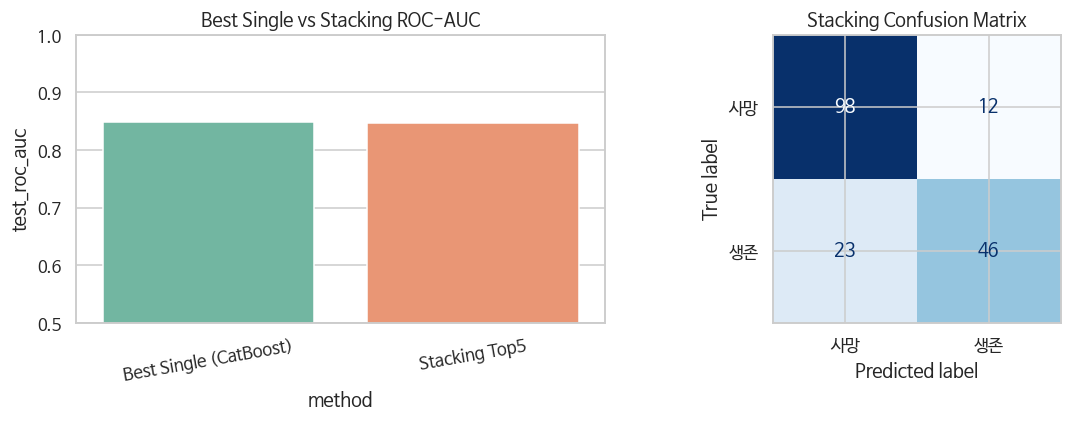

In [13]:
final_compare = pd.DataFrame({
    'method': [f'Best Single ({best_single_name})', 'Stacking Top5'],
    'test_accuracy': [acc_single, acc_stack],
    'test_f1': [f1_single, f1_stack],
    'test_roc_auc': [auc_single, auc_stack],
})

display(final_compare.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=final_compare, x='method', y='test_roc_auc', ax=axes[0], palette='Set2')
axes[0].set_title('Best Single vs Stacking ROC-AUC')
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis='x', rotation=10)

cm = confusion_matrix(y_test, y_pred_stack)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['사망', '생존']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title('Stacking Confusion Matrix')

plt.tight_layout()
plt.show()


## 11. SHAP 해석 (최종 모델)

튜닝된 **Best Single 모델**에 대해 SHAP으로 변수 기여도를 확인합니다.

1. `preprocessor`로 변환된 학습 행렬을 만듭니다.
2. 트리 기반 모델이면 `shap.TreeExplainer`를 사용합니다.
3. 이진 분류는 **생존 클래스(1)** 기준 SHAP 값을 해석합니다.


In [14]:
explain_pipe = best_single_model
preprocessed_model = explain_pipe.named_steps['model']
transformed_train = explain_pipe.named_steps['preprocessor'].transform(X_train)
feature_names = explain_pipe.named_steps['preprocessor'].get_feature_names_out()

rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(300, transformed_train.shape[0])
sample_idx = rng.choice(transformed_train.shape[0], size=sample_size, replace=False)
X_shap = transformed_train[sample_idx]

tree_types = (
    DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier,
    XGBClassifier, LGBMClassifier, CatBoostClassifier,
)
if isinstance(preprocessed_model, tree_types):
    explainer = shap.TreeExplainer(preprocessed_model)
    shap_values = explainer.shap_values(X_shap)
else:
    explainer = shap.Explainer(preprocessed_model.predict_proba, X_shap)
    shap_values = explainer(X_shap).values

# 이진 분류: list 또는 3차원 배열이면 생존 클래스(1) 기준으로 선택
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif getattr(shap_values, 'ndim', 2) == 3:
    shap_values = shap_values[:, :, 1]

print('SHAP sample shape:', X_shap.shape)
print('Explainer type:', type(explainer).__name__)


SHAP sample shape: (300, 19)
Explainer type: TreeExplainer


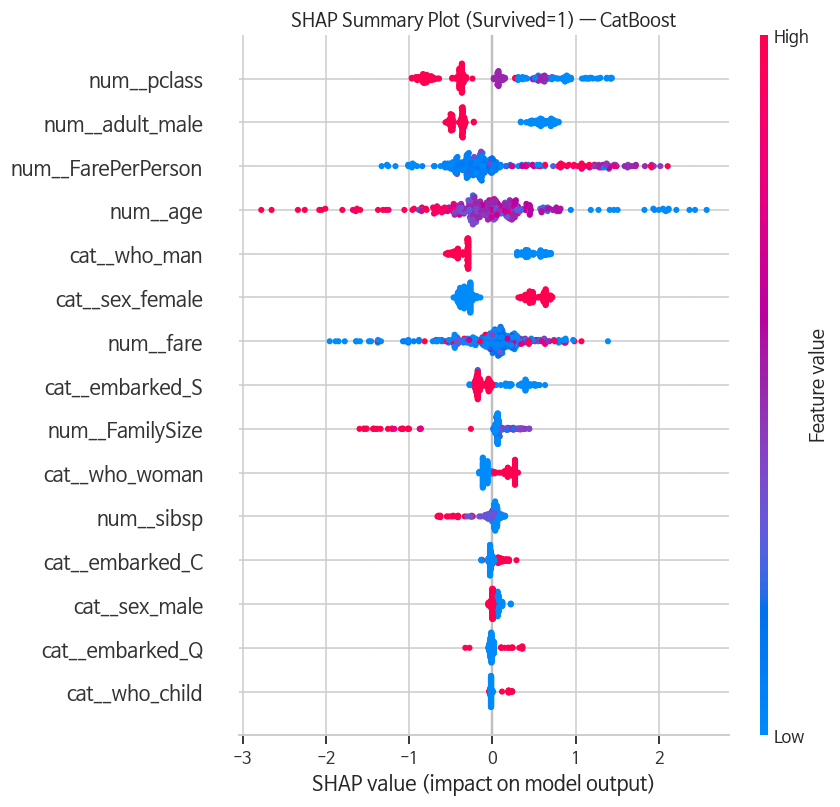

In [16]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False,
    max_display=15,
)
plt.title(f'SHAP Summary Plot (Survived=1) — {best_single_name}')
plt.tight_layout()
plt.show()


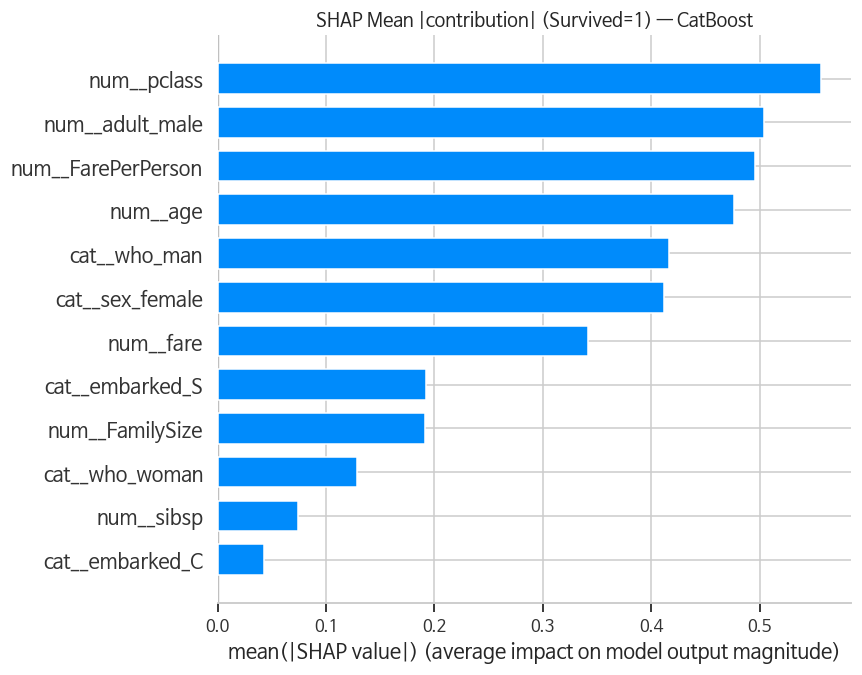

In [17]:
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    max_display=12,
)
plt.title(f'SHAP Mean |contribution| (Survived=1) — {best_single_name}')
plt.tight_layout()
plt.show()


## 12. 정리

1. **train/test 분리 후** `X_train`에 파생변수를 만들고, 같은 함수를 `X_test`에 적용했습니다.
2. **sklearn 1.6.1** 스타일 `OneHotEncoder(sparse_output=False)` Pipeline을 사용했습니다.
3. 10개 모델을 **학습 시간 + CV ROC-AUC**로 비교하고, 사분면 scatter로 위치를 시각화했습니다.
4. 상위 5개를 Stacking하고, **SHAP**으로 최종 단일 모델을 해석했습니다.
5. 로컬 테스트 데이터는 마지막 단일 vs Stacking 비교에만 사용했습니다.
